# COMPAS postprocessing

It evaluates whether a postprocessed version of the fairness-aware contextual bandit can improve fairness on **COMPAS** with only a limited accuracy cost.

Compared methods:

- `LinUCB`
- `GroupAwareDPLinUCB`
- `GroupAwareDPLinUCB_PostProc`
- `LogisticRegression`
- `RandomForest`

The postprocessor:
- fits the fairness-aware bandit on a training stream
- computes margins on a calibration split
- learns one threshold per sensitive group
- applies those thresholds on the test set

In [1]:
from pathlib import Path
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from fair_bandits.config import build_config
from fair_bandits.data import (
    load_compas,
    clean_compas_minimal,
    ensure_compas_race_binary,
    compas_reward_from_recid,
    make_group_label_sampling_probs,
)
from fair_bandits.metrics import summarize_metrics, mean_ci
from fair_bandits.policies import LinUCB, GroupAwareDPLinUCB
from fair_bandits.experiments import compare_methods

In [2]:
CFG = build_config("full")   # switch to "full" for thesis runs

DATASET_NAME = "compas"
SENSITIVE_COLS = ["sex", "race_binary"]
PREPROCESSINGS = ["uniform", "reweigh_group_label"]
HORIZONS = [50, 100, 250, 500]
SEEDS = [CFG.seed0 + i for i in range(max(5, CFG.n_seeds))]

TEST_SIZE = 0.30
CALIBRATION_SIZE = 0.25   # split from the training fold

POSTPROC_METHOD_NAME = "GroupAwareDPLinUCB_PostProc"
METHOD_ORDER = [
    "LinUCB",
    "GroupAwareDPLinUCB",
    POSTPROC_METHOD_NAME,
    "LogisticRegression",
    "RandomForest",
]

POSTPROC_TARGET_METRIC = "DP_gap"
POSTPROC_MAX_ACC_DROP = 0.01
POSTPROC_GRID_SIZE = 31
RUN_MISSING = True

KEY_METRICS = [
    "accuracy",
    "DP_gap",
    "TPR_gap",
    "FPR_gap",
    "EO_gap",
    "PPV_gap",
    "UtilityGap",
    "CumulativeRegret",
]

RESULTS_DIR = CFG.results_dir / "compas_postprocessing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CFG

ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

### Load and clean COMPAS

In [3]:
df_raw = load_compas(cache_dir=CFG.cache_dir)
df_raw = clean_compas_minimal(df_raw)
df_raw = ensure_compas_race_binary(df_raw)

print("Shape after cleaning:", df_raw.shape)
display(df_raw.head())

Shape after cleaning: (7214, 10)


,sex,race,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,race_binary
0,Male,Other,69,0,0,0,0,F,0,Non-White
1,Male,African-American,34,0,0,0,0,F,1,Non-White
2,Male,African-American,24,0,0,1,4,F,1,Non-White
3,Male,African-American,23,0,1,0,1,F,0,Non-White
4,Male,Other,43,0,0,0,2,F,0,Non-White


### Leakage-aware helpers

In [4]:
def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def _compas_feature_columns(df: pd.DataFrame, sensitive_col: str) -> list[str]:
    cols = [c for c in df.columns if c != "two_year_recid"]
    drop_cols = {sensitive_col}
    if sensitive_col == "race_binary":
        drop_cols.add("race")
    if sensitive_col == "race":
        drop_cols.add("race_binary")
    return [c for c in cols if c not in drop_cols]


def prepare_train_and_eval_matrices(
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    sensitive_col: str,
):
    train_df = ensure_compas_race_binary(clean_compas_minimal(train_df.copy()))
    eval_df = ensure_compas_race_binary(clean_compas_minimal(eval_df.copy()))

    feature_cols = _compas_feature_columns(train_df, sensitive_col=sensitive_col)
    X_train_df = train_df[feature_cols].copy()
    X_eval_df = eval_df[feature_cols].copy()

    y_train = compas_reward_from_recid(train_df["two_year_recid"])
    y_eval = compas_reward_from_recid(eval_df["two_year_recid"])

    group_train = train_df[sensitive_col].astype(str).fillna("Unknown").to_numpy()
    group_eval = eval_df[sensitive_col].astype(str).fillna("Unknown").to_numpy()

    num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train_df[c])]
    cat_cols = [c for c in feature_cols if c not in num_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", _make_ohe()),
    ])

    preproc = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
    )

    X_train = np.asarray(preproc.fit_transform(X_train_df), dtype=np.float32)
    X_eval = np.asarray(preproc.transform(X_eval_df), dtype=np.float32)

    return X_train, y_train, group_train, X_eval, y_eval, group_eval

### Policy fitting and prediction

In [5]:
def fit_bandit_policy_on_prefix(
    X_train: np.ndarray,
    y_train: np.ndarray,
    group_train: np.ndarray,
    idx_prefix: np.ndarray,
    method_name: str,
    cfg,
):
    d = int(X_train.shape[1])

    if method_name == "LinUCB":
        policy = LinUCB(d=d, alpha=cfg.alpha_linucb, lam=cfg.lambda_ridge)
    elif method_name == "GroupAwareDPLinUCB":
        policy = GroupAwareDPLinUCB(
            d=d,
            groups=group_train,
            alpha=cfg.alpha_linucb,
            lam=cfg.lambda_ridge,
            tau=cfg.dp_tau,
            lambda_fair=cfg.dp_lambda,
            beta_smooth=cfg.beta_smooth,
            min_group_count=cfg.min_group_count,
        )
    else:
        raise ValueError(f"Unsupported bandit method: {method_name}")

    for i in idx_prefix:
        x = X_train[int(i)]
        yt = int(y_train[int(i)])
        g = str(group_train[int(i)])
        a = int(policy.select(x, g))
        r = float(a == yt)
        policy.update(x, a, r, g)

    return policy


def predict_with_bandit_policy(policy, X_eval: np.ndarray, group_eval: np.ndarray) -> np.ndarray:
    preds = []
    for x, g in zip(X_eval, group_eval):
        preds.append(int(policy.select(x, str(g))))
    return np.asarray(preds, dtype=int)


def fit_supervised_prefix_model(
    X_prefix: np.ndarray,
    y_prefix: np.ndarray,
    method_name: str,
    seed: int,
):
    y_prefix = np.asarray(y_prefix, dtype=int)

    if np.unique(y_prefix).size < 2:
        clf = DummyClassifier(strategy="constant", constant=int(y_prefix[0]))
        clf.fit(X_prefix, y_prefix)
        return clf

    if method_name == "LogisticRegression":
        clf = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=seed)
    elif method_name == "RandomForest":
        clf = RandomForestClassifier(n_estimators=400, random_state=seed, n_jobs=-1)
    else:
        raise ValueError(f"Unsupported supervised method: {method_name}")

    clf.fit(X_prefix, y_prefix)
    return clf

### Group-threshold postprocessor

In [6]:
def fairlinucb_groupaware_scores(policy, x: np.ndarray, group: str) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    g = str(group)

    scores = np.zeros(policy.n_actions, dtype=np.float32)
    for a in range(policy.n_actions):
        theta = policy._theta(a)
        mean = float(theta @ x)
        var = float(x @ (policy.A_inv[a] @ x))
        ucb = mean + policy.alpha * np.sqrt(max(var, 0.0))
        penalty = policy._fair_penalty(g, a)
        scores[a] = ucb - penalty
    return scores


def fairlinucb_groupaware_margin(policy, X: np.ndarray, group: np.ndarray) -> np.ndarray:
    margins = []
    for x, g in zip(X, group):
        s = fairlinucb_groupaware_scores(policy, x, str(g))
        margins.append(float(s[1] - s[0]))
    return np.asarray(margins, dtype=float)


def predict_with_group_thresholds(policy, X: np.ndarray, group: np.ndarray, thresholds: dict[str, float]) -> np.ndarray:
    margins = fairlinucb_groupaware_margin(policy, X, group)
    preds = np.array(
        [int(m >= thresholds[str(g)]) for m, g in zip(margins, group)],
        dtype=int,
    )
    return preds


def fit_group_threshold_postprocessor(
    policy,
    X_cal: np.ndarray,
    y_cal: np.ndarray,
    group_cal: np.ndarray,
    *,
    target_metric: str = "DP_gap",
    max_acc_drop: float = 0.01,
    grid_size: int = 31,
):
    X_cal = np.asarray(X_cal)
    y_cal = np.asarray(y_cal).astype(int)
    group_cal = np.asarray(group_cal).astype(str)

    uniq_groups = sorted(np.unique(group_cal).tolist())
    if len(uniq_groups) != 2:
        raise ValueError(f"This version expects exactly 2 groups, got: {uniq_groups}")

    raw_preds = predict_with_bandit_policy(policy, X_cal, group_cal)
    raw_reward = (raw_preds == y_cal).astype(float)
    raw_metrics = summarize_metrics(
        y_true=y_cal,
        y_hat=raw_preds,
        group=group_cal,
        reward=raw_reward,
        oracle_reward=1.0,
    )
    baseline_acc = float(raw_metrics["accuracy"])

    margins = fairlinucb_groupaware_margin(policy, X_cal, group_cal)
    lo, hi = np.quantile(margins, [0.05, 0.95])
    grid = np.linspace(lo, hi, int(grid_size))
    grid = np.unique(np.concatenate([grid, [0.0]]))

    g1, g2 = uniq_groups
    is_g1 = (group_cal == g1)

    best = None
    search_rows = []

    for t1, t2 in product(grid, repeat=2):
        thr_vec = np.where(is_g1, t1, t2)
        y_hat = (margins >= thr_vec).astype(int)
        reward = (y_hat == y_cal).astype(float)
        met = summarize_metrics(
            y_true=y_cal,
            y_hat=y_hat,
            group=group_cal,
            reward=reward,
            oracle_reward=1.0,
        )

        row = {
            f"threshold_{g1}": float(t1),
            f"threshold_{g2}": float(t2),
            **met,
        }
        search_rows.append(row)

        acc = float(met["accuracy"])
        fairness_value = float(met[target_metric])

        feasible = acc >= baseline_acc - max_acc_drop
        if not feasible:
            continue

        score = (fairness_value, -acc)
        if best is None or score < best["score"]:
            best = {
                "thresholds": {g1: float(t1), g2: float(t2)},
                "metrics": met,
                "score": score,
            }

    if best is None:
        best = {
            "thresholds": {g1: 0.0, g2: 0.0},
            "metrics": raw_metrics,
            "score": (float(raw_metrics[target_metric]), -baseline_acc),
        }

    search_df = pd.DataFrame(search_rows).sort_values(
        [target_metric, "accuracy"], ascending=[True, False]
    ).reset_index(drop=True)

    return best["thresholds"], search_df, raw_metrics, best["metrics"]

### Evaluation helpers

In [7]:
def evaluate_predictions_to_long_rows(
    *,
    dataset: str,
    sensitive: str,
    preprocessing: str,
    horizon: int,
    seed: int,
    method: str,
    y_true: np.ndarray,
    y_hat: np.ndarray,
    group: np.ndarray,
):
    reward = (np.asarray(y_true, dtype=int) == np.asarray(y_hat, dtype=int)).astype(float)
    met = summarize_metrics(
        y_true=np.asarray(y_true, dtype=int),
        y_hat=np.asarray(y_hat, dtype=int),
        group=np.asarray(group).astype(str),
        reward=reward,
        oracle_reward=1.0,
    )

    rows = []
    for metric in KEY_METRICS:
        rows.append({
            "dataset": dataset,
            "sensitive": sensitive,
            "preprocessing": preprocessing,
            "horizon": int(horizon),
            "seed": int(seed),
            "method": method,
            "metric": metric,
            "value": float(met[metric]),
            "n_eval": int(len(y_true)),
        })
    return rows


def summarize_long_with_ci(long_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["dataset", "sensitive", "preprocessing", "horizon", "method", "metric"]
    for keys, sub in long_df.groupby(group_cols):
        mu, lo, hi = mean_ci(sub["value"].to_numpy(dtype=float), alpha=0.05)
        rows.append({
            **dict(zip(group_cols, keys)),
            "mean": mu,
            "ci_low": lo,
            "ci_high": hi,
            "n_seeds": int(sub["seed"].nunique()),
        })
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)

### Run postprocessing benchmark or load cached results

In [8]:
def run_compas_postprocessing_benchmark(
    *,
    df_raw: pd.DataFrame,
    cfg,
    sensitive_list: list[str],
    preprocessing_modes: list[str],
    horizons: list[int],
    seeds: list[int],
):
    rows = []
    search_tables = {}

    df_src = ensure_compas_race_binary(clean_compas_minimal(df_raw.copy()))
    y_for_split = compas_reward_from_recid(df_src["two_year_recid"])

    for sensitive in sensitive_list:
        for preprocessing in preprocessing_modes:
            for seed in seeds:
                outer_train_df, test_df = train_test_split(
                    df_src,
                    test_size=TEST_SIZE,
                    random_state=int(seed),
                    stratify=y_for_split,
                )

                y_outer = compas_reward_from_recid(outer_train_df["two_year_recid"])
                bandit_train_df, cal_df = train_test_split(
                    outer_train_df,
                    test_size=CALIBRATION_SIZE,
                    random_state=int(seed),
                    stratify=y_outer,
                )

                X_train, y_train, group_train, X_cal, y_cal, group_cal = prepare_train_and_eval_matrices(
                    bandit_train_df,
                    cal_df,
                    sensitive_col=sensitive,
                )
                X_train_2, y_train_2, group_train_2, X_test, y_test, group_test = prepare_train_and_eval_matrices(
                    bandit_train_df,
                    test_df,
                    sensitive_col=sensitive,
                )

                # sanity: train matrices must match exactly
                if X_train.shape != X_train_2.shape or not np.array_equal(y_train, y_train_2):
                    raise ValueError("Train matrices differ across calibration/test preparation; check preprocessing logic.")

                sampling_probs = None
                if preprocessing == "reweigh_group_label":
                    sampling_probs = make_group_label_sampling_probs(group_train, y_train)

                for horizon in horizons:
                    rng = np.random.default_rng(int(seed))
                    idx_prefix = rng.choice(
                        len(X_train),
                        size=int(horizon),
                        replace=True,
                        p=sampling_probs,
                    )

                    X_prefix = X_train[idx_prefix]
                    y_prefix = y_train[idx_prefix]

                    lin_policy = fit_bandit_policy_on_prefix(
                        X_train=X_train,
                        y_train=y_train,
                        group_train=group_train,
                        idx_prefix=idx_prefix,
                        method_name="LinUCB",
                        cfg=cfg,
                    )
                    fair_policy = fit_bandit_policy_on_prefix(
                        X_train=X_train,
                        y_train=y_train,
                        group_train=group_train,
                        idx_prefix=idx_prefix,
                        method_name="GroupAwareDPLinUCB",
                        cfg=cfg,
                    )

                    lr_clf = fit_supervised_prefix_model(
                        X_prefix=X_prefix,
                        y_prefix=y_prefix,
                        method_name="LogisticRegression",
                        seed=int(seed),
                    )
                    rf_clf = fit_supervised_prefix_model(
                        X_prefix=X_prefix,
                        y_prefix=y_prefix,
                        method_name="RandomForest",
                        seed=int(seed),
                    )

                    lin_test_pred = predict_with_bandit_policy(lin_policy, X_test, group_test)
                    fair_test_pred = predict_with_bandit_policy(fair_policy, X_test, group_test)
                    lr_test_pred = lr_clf.predict(X_test).astype(int)
                    rf_test_pred = rf_clf.predict(X_test).astype(int)

                    thresholds, search_df, raw_cal_metrics, best_cal_metrics = fit_group_threshold_postprocessor(
                        fair_policy,
                        X_cal,
                        y_cal,
                        group_cal,
                        target_metric=POSTPROC_TARGET_METRIC,
                        max_acc_drop=POSTPROC_MAX_ACC_DROP,
                        grid_size=POSTPROC_GRID_SIZE,
                    )
                    post_test_pred = predict_with_group_thresholds(
                        fair_policy,
                        X_test,
                        group_test,
                        thresholds=thresholds,
                    )

                    search_key = (sensitive, preprocessing, seed, horizon)
                    search_tables[search_key] = search_df.copy()

                    rows.extend(
                        evaluate_predictions_to_long_rows(
                            dataset=DATASET_NAME,
                            sensitive=sensitive,
                            preprocessing=preprocessing,
                            horizon=horizon,
                            seed=seed,
                            method="LinUCB",
                            y_true=y_test,
                            y_hat=lin_test_pred,
                            group=group_test,
                        )
                    )
                    rows.extend(
                        evaluate_predictions_to_long_rows(
                            dataset=DATASET_NAME,
                            sensitive=sensitive,
                            preprocessing=preprocessing,
                            horizon=horizon,
                            seed=seed,
                            method="GroupAwareDPLinUCB",
                            y_true=y_test,
                            y_hat=fair_test_pred,
                            group=group_test,
                        )
                    )
                    rows.extend(
                        evaluate_predictions_to_long_rows(
                            dataset=DATASET_NAME,
                            sensitive=sensitive,
                            preprocessing=preprocessing,
                            horizon=horizon,
                            seed=seed,
                            method=POSTPROC_METHOD_NAME,
                            y_true=y_test,
                            y_hat=post_test_pred,
                            group=group_test,
                        )
                    )
                    rows.extend(
                        evaluate_predictions_to_long_rows(
                            dataset=DATASET_NAME,
                            sensitive=sensitive,
                            preprocessing=preprocessing,
                            horizon=horizon,
                            seed=seed,
                            method="LogisticRegression",
                            y_true=y_test,
                            y_hat=lr_test_pred,
                            group=group_test,
                        )
                    )
                    rows.extend(
                        evaluate_predictions_to_long_rows(
                            dataset=DATASET_NAME,
                            sensitive=sensitive,
                            preprocessing=preprocessing,
                            horizon=horizon,
                            seed=seed,
                            method="RandomForest",
                            y_true=y_test,
                            y_hat=rf_test_pred,
                            group=group_test,
                        )
                    )

    perseed_long = pd.DataFrame(rows).sort_values(
        ["dataset", "sensitive", "preprocessing", "horizon", "seed", "method", "metric"]
    ).reset_index(drop=True)
    ci_long = summarize_long_with_ci(perseed_long)

    friedman_frames = []
    pairwise_frames = []

    lower_is_better_metrics = {"DP_gap", "TPR_gap", "FPR_gap", "EO_gap", "PPV_gap", "UtilityGap", "CumulativeRegret"}

    for metric in perseed_long["metric"].dropna().unique().tolist():
        sub = perseed_long[perseed_long["metric"] == metric].copy()
        friedman_df, pairwise_df = compare_methods(
            sub,
            value_col="value",
            method_col="method",
            seed_col="seed",
            group_cols=["dataset", "sensitive", "preprocessing", "horizon", "metric"],
            lower_is_better=(metric in lower_is_better_metrics),
        )
        if not friedman_df.empty:
            friedman_frames.append(friedman_df)
        if not pairwise_df.empty:
            pairwise_frames.append(pairwise_df)

    friedman_all = pd.concat(friedman_frames, ignore_index=True) if friedman_frames else pd.DataFrame()
    pairwise_all = pd.concat(pairwise_frames, ignore_index=True) if pairwise_frames else pd.DataFrame()

    return perseed_long, ci_long, friedman_all, pairwise_all, search_tables


perseed_path = RESULTS_DIR / "compas_postproc_perseed_long.csv"
ci_path = RESULTS_DIR / "compas_postproc_ci_long.csv"
friedman_path = RESULTS_DIR / "compas_postproc_friedman.csv"
pairwise_path = RESULTS_DIR / "compas_postproc_pairwise_df.csv"

if RUN_MISSING or not (perseed_path.exists() and ci_path.exists() and pairwise_path.exists()):
    postproc_perseed_long, postproc_ci_long, postproc_friedman_df, postproc_pairwise_df, postproc_search_tables = run_compas_postprocessing_benchmark(
        df_raw=df_raw,
        cfg=CFG,
        sensitive_list=SENSITIVE_COLS,
        preprocessing_modes=PREPROCESSINGS,
        horizons=HORIZONS,
        seeds=SEEDS,
    )

    postproc_perseed_long.to_csv(perseed_path, index=False)
    postproc_ci_long.to_csv(ci_path, index=False)
    postproc_friedman_df.to_csv(friedman_path, index=False)
    postproc_pairwise_df.to_csv(pairwise_path, index=False)

    print("Saved postprocessing benchmark outputs to:")
    print(" ", perseed_path.resolve())
    print(" ", ci_path.resolve())
    print(" ", friedman_path.resolve())
    print(" ", pairwise_path.resolve())
else:
    postproc_perseed_long = pd.read_csv(perseed_path)
    postproc_ci_long = pd.read_csv(ci_path)
    postproc_friedman_df = pd.read_csv(friedman_path) if friedman_path.exists() else pd.DataFrame()
    postproc_pairwise_df = pd.read_csv(pairwise_path)
    postproc_search_tables = {}
    print("Loaded cached postprocessing benchmark outputs from:")
    print(" ", perseed_path.resolve())

Saved postprocessing benchmark outputs to:
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_postprocessing\compas_postproc_perseed_long.csv
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_postprocessing\compas_postproc_ci_long.csv
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_postprocessing\compas_postproc_friedman.csv
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_postprocessing\compas_postproc_pairwise_df.csv


In [9]:
print("Shapes:")
print("  postproc_perseed_long:", postproc_perseed_long.shape)
print("  postproc_ci_long     :", postproc_ci_long.shape)
print("  postproc_friedman_df :", postproc_friedman_df.shape)
print("  postproc_pairwise_df :", postproc_pairwise_df.shape)

display(postproc_ci_long.head(24))
display(postproc_pairwise_df.head(24))

Shapes:
  postproc_perseed_long: (32000, 9)
  postproc_ci_long     : (640, 10)
  postproc_friedman_df : (128, 11)
  postproc_pairwise_df : (1280, 16)


,dataset,sensitive,preprocessing,horizon,method,metric,mean,ci_low,ci_high,n_seeds
0,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,CumulativeRegret,881.980000,738.900000,1092.450000,50
1,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,DP_gap,0.138342,0.009710,0.423144,50
2,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,EO_gap,0.159192,0.017414,0.462636,50
3,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,FPR_gap,0.134896,0.003209,0.347348,50
4,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,PPV_gap,0.064691,0.005691,0.163174,50
5,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,TPR_gap,0.132898,0.006657,0.439835,50
6,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,UtilityGap,0.033454,0.002659,0.100983,50
7,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,accuracy,0.592619,0.495404,0.658707,50
8,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB_PostProc,CumulativeRegret,855.240000,747.925000,982.900000,50
9,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB_PostProc,DP_gap,0.024551,0.000691,0.062445,50


,dataset,sensitive,preprocessing,horizon,metric,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,GroupAwareDPLinUCB_PostProc,50,881.98,855.24,26.74,294.0,2.562176e-03,GroupAwareDPLinUCB_PostProc,1.537305e-02
1,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,LinUCB,50,881.98,872.84,9.14,338.5,2.331361e-01,LinUCB,2.331361e-01
2,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,LogisticRegression,50,881.98,840.72,41.26,217.5,5.023763e-05,LogisticRegression,4.019010e-04
3,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,RandomForest,50,881.98,899.36,-17.38,439.5,5.593399e-02,GroupAwareDPLinUCB,2.237360e-01
4,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB_PostProc,LinUCB,50,855.24,872.84,-17.60,425.0,6.215035e-02,GroupAwareDPLinUCB_PostProc,2.237360e-01
5,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB_PostProc,LogisticRegression,50,855.24,840.72,14.52,440.0,8.616328e-02,LogisticRegression,2.237360e-01
6,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB_PostProc,RandomForest,50,855.24,899.36,-44.12,210.5,3.754047e-05,GroupAwareDPLinUCB_PostProc,3.378643e-04
7,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LinUCB,LogisticRegression,50,872.84,840.72,32.12,281.5,5.887445e-04,LogisticRegression,4.121211e-03
8,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LinUCB,RandomForest,50,872.84,899.36,-26.52,366.5,1.439705e-02,LinUCB,7.198527e-02
9,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LogisticRegression,RandomForest,50,840.72,899.36,-58.64,153.5,2.973783e-06,LogisticRegression,2.973783e-05


### Final-horizon summary

In [10]:
final_horizon = max(HORIZONS)

final_ci = postproc_ci_long[
    (postproc_ci_long["horizon"] == final_horizon) &
    (postproc_ci_long["metric"].isin(["accuracy", "DP_gap", "EO_gap", "PPV_gap"]))
].copy()

final_ci["mean_ci"] = final_ci.apply(
    lambda r: f"{r['mean']:.3f} [{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
    axis=1,
)

final_summary = (
    final_ci
    .pivot_table(
        index=["dataset", "sensitive", "preprocessing", "metric"],
        columns="method",
        values="mean_ci",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(["sensitive", "preprocessing", "metric"])
    .reset_index(drop=True)
)

display(final_summary)

method,dataset,sensitive,preprocessing,metric,GroupAwareDPLinUCB,GroupAwareDPLinUCB_PostProc,LinUCB,LogisticRegression,RandomForest
0,compas,race_binary,reweigh_group_label,DP_gap,"0.104 [0.008, 0.185]","0.031 [0.003, 0.075]","0.183 [0.138, 0.227]","0.184 [0.143, 0.230]","0.109 [0.063, 0.160]"
1,compas,race_binary,reweigh_group_label,EO_gap,"0.119 [0.037, 0.215]","0.059 [0.016, 0.112]","0.189 [0.131, 0.252]","0.193 [0.141, 0.256]","0.114 [0.071, 0.175]"
2,compas,race_binary,reweigh_group_label,PPV_gap,"0.028 [0.001, 0.072]","0.057 [0.018, 0.102]","0.018 [0.001, 0.058]","0.020 [0.001, 0.060]","0.047 [0.011, 0.079]"
3,compas,race_binary,reweigh_group_label,accuracy,"0.655 [0.627, 0.682]","0.654 [0.625, 0.675]","0.654 [0.617, 0.687]","0.655 [0.624, 0.687]","0.597 [0.574, 0.626]"
4,compas,race_binary,uniform,DP_gap,"0.073 [0.003, 0.171]","0.026 [0.001, 0.075]","0.168 [0.128, 0.212]","0.164 [0.120, 0.218]","0.111 [0.057, 0.149]"
5,compas,race_binary,uniform,EO_gap,"0.096 [0.029, 0.201]","0.062 [0.022, 0.105]","0.191 [0.119, 0.250]","0.189 [0.133, 0.244]","0.123 [0.074, 0.192]"
6,compas,race_binary,uniform,PPV_gap,"0.048 [0.012, 0.085]","0.063 [0.022, 0.108]","0.025 [0.001, 0.065]","0.028 [0.002, 0.066]","0.051 [0.004, 0.096]"
7,compas,race_binary,uniform,accuracy,"0.662 [0.640, 0.679]","0.657 [0.632, 0.681]","0.666 [0.647, 0.684]","0.666 [0.646, 0.683]","0.606 [0.575, 0.629]"
8,compas,sex,reweigh_group_label,DP_gap,"0.073 [0.003, 0.145]","0.035 [0.002, 0.085]","0.105 [0.060, 0.172]","0.109 [0.066, 0.162]","0.084 [0.035, 0.135]"
9,compas,sex,reweigh_group_label,EO_gap,"0.073 [0.016, 0.154]","0.069 [0.015, 0.152]","0.089 [0.041, 0.151]","0.095 [0.043, 0.151]","0.087 [0.023, 0.166]"


### Focus table: comparisons involving the postprocessed method

In [11]:
focus_pairwise = postproc_pairwise_df[
    (postproc_pairwise_df["horizon"] == final_horizon) &
    (postproc_pairwise_df["metric"].isin(["accuracy", "DP_gap", "EO_gap", "PPV_gap"])) &
    (
        (postproc_pairwise_df["method_a"] == POSTPROC_METHOD_NAME) |
        (postproc_pairwise_df["method_b"] == POSTPROC_METHOD_NAME)
    )
].copy()

if not focus_pairwise.empty:
    focus_pairwise = focus_pairwise.sort_values(
        ["sensitive", "preprocessing", "metric", "method_a", "method_b"]
    ).reset_index(drop=True)

display(focus_pairwise)

,dataset,sensitive,preprocessing,horizon,metric,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,compas,race_binary,reweigh_group_label,500,DP_gap,value,GroupAwareDPLinUCB,GroupAwareDPLinUCB_PostProc,50,0.103743,0.030794,0.072949,42.0,1.387441e-08,GroupAwareDPLinUCB_PostProc,4.162323e-08
1,compas,race_binary,reweigh_group_label,500,DP_gap,value,GroupAwareDPLinUCB_PostProc,LinUCB,50,0.030794,0.182861,-0.152067,0.0,1.776357e-15,GroupAwareDPLinUCB_PostProc,1.776357e-14
2,compas,race_binary,reweigh_group_label,500,DP_gap,value,GroupAwareDPLinUCB_PostProc,LogisticRegression,50,0.030794,0.184325,-0.153531,0.0,1.776357e-15,GroupAwareDPLinUCB_PostProc,1.776357e-14
3,compas,race_binary,reweigh_group_label,500,DP_gap,value,GroupAwareDPLinUCB_PostProc,RandomForest,50,0.030794,0.108585,-0.077791,2.0,5.329071e-15,GroupAwareDPLinUCB_PostProc,3.197442e-14
4,compas,race_binary,reweigh_group_label,500,EO_gap,value,GroupAwareDPLinUCB,GroupAwareDPLinUCB_PostProc,50,0.118524,0.059125,0.059399,73.0,8.025009e-08,GroupAwareDPLinUCB_PostProc,2.407503e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,compas,sex,uniform,500,PPV_gap,value,GroupAwareDPLinUCB_PostProc,RandomForest,50,0.095224,0.081906,0.013319,331.0,2.614124e-03,RandomForest,1.010274e-02
60,compas,sex,uniform,500,accuracy,value,GroupAwareDPLinUCB,GroupAwareDPLinUCB_PostProc,50,0.661533,0.655520,0.006014,129.0,1.507560e-06,GroupAwareDPLinUCB,9.045360e-06
61,compas,sex,uniform,500,accuracy,value,GroupAwareDPLinUCB_PostProc,LinUCB,50,0.655520,0.660776,-0.005256,212.5,1.172946e-04,LinUCB,4.691786e-04
62,compas,sex,uniform,500,accuracy,value,GroupAwareDPLinUCB_PostProc,LogisticRegression,50,0.655520,0.662753,-0.007233,182.0,1.094384e-05,LogisticRegression,5.471918e-05


## Postprocessed method versus baselines across horizons

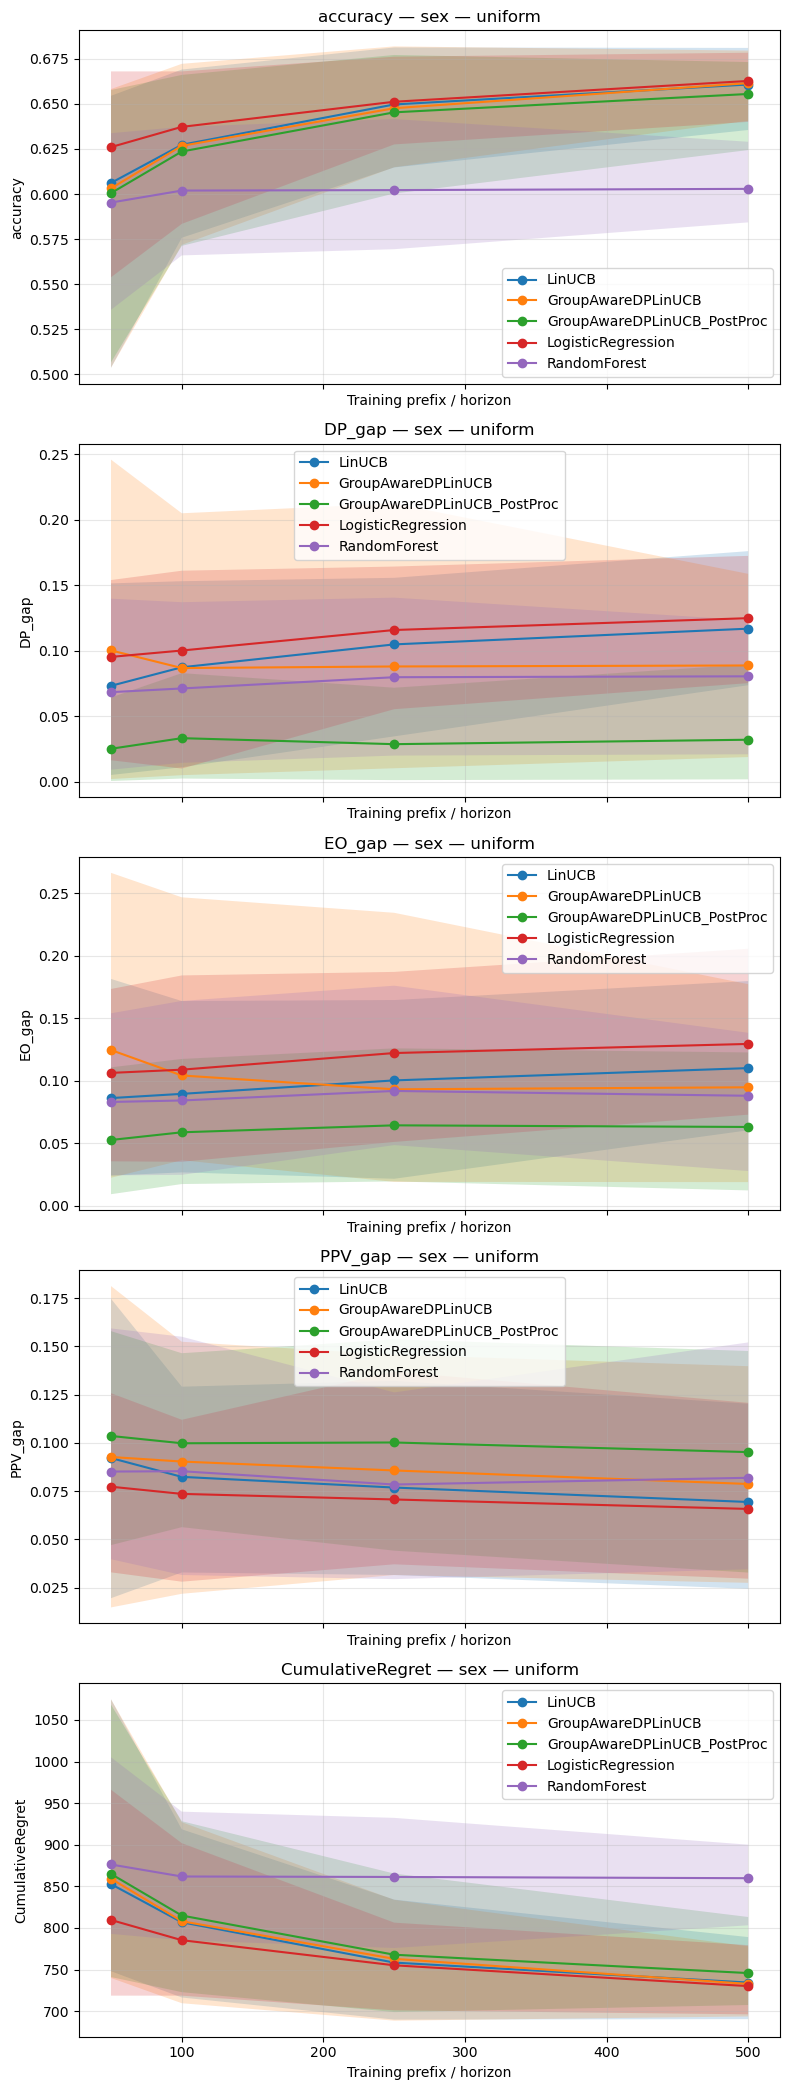

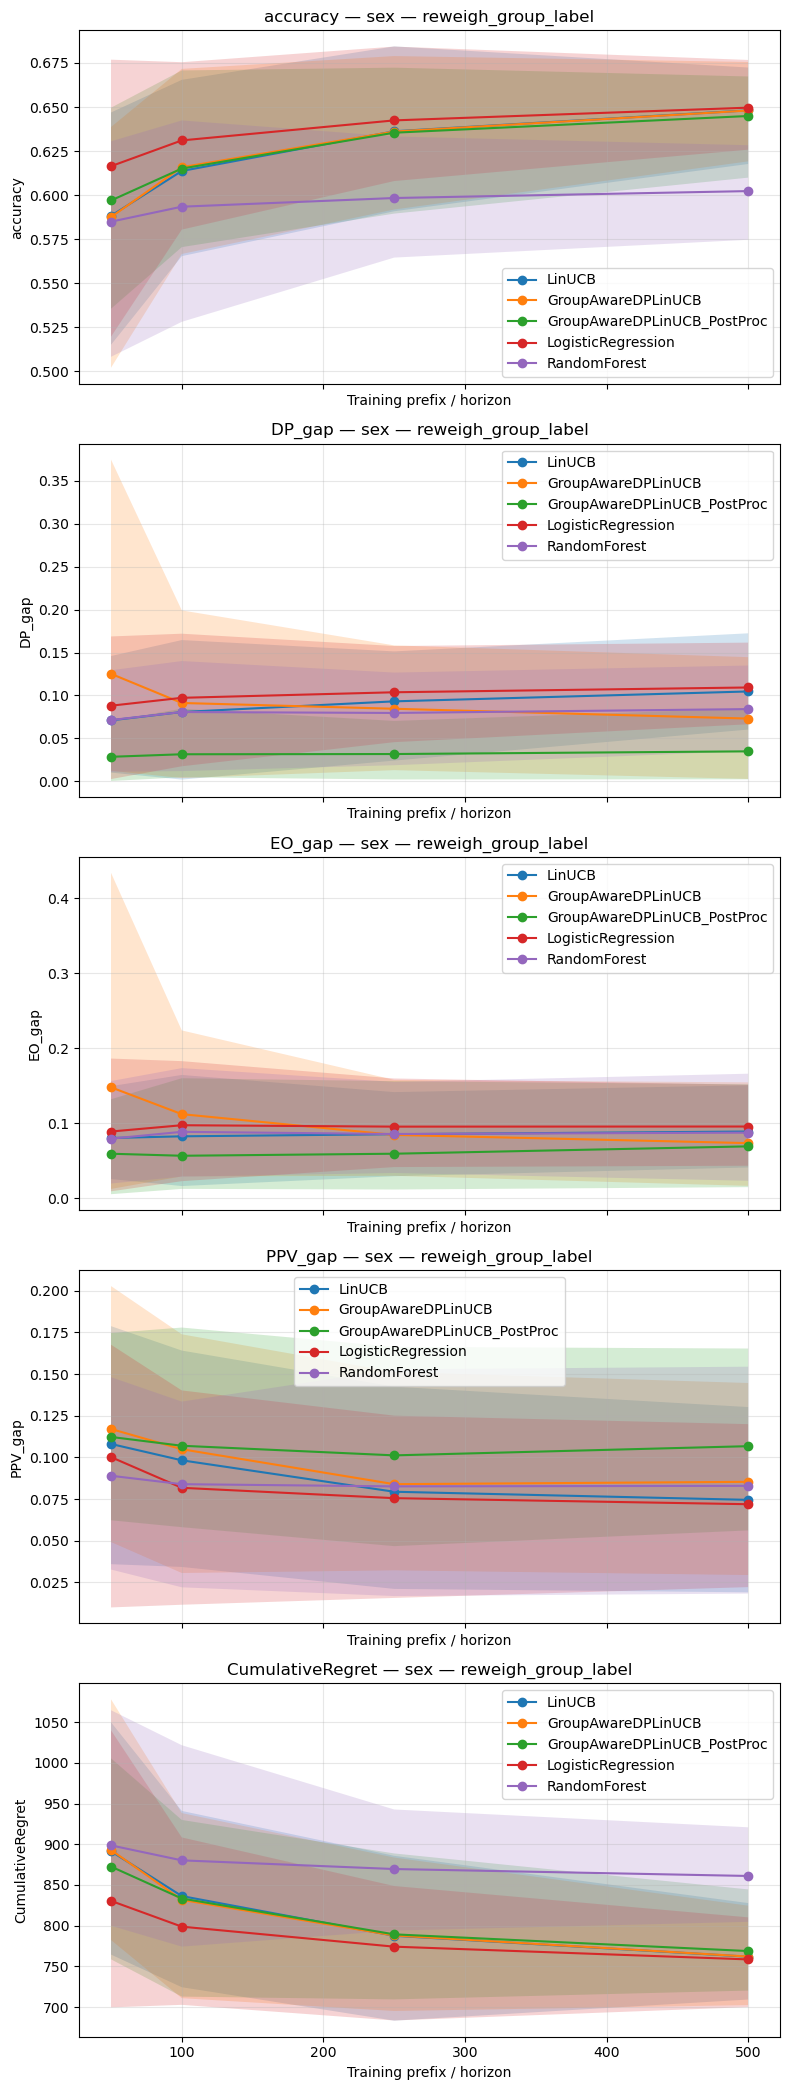

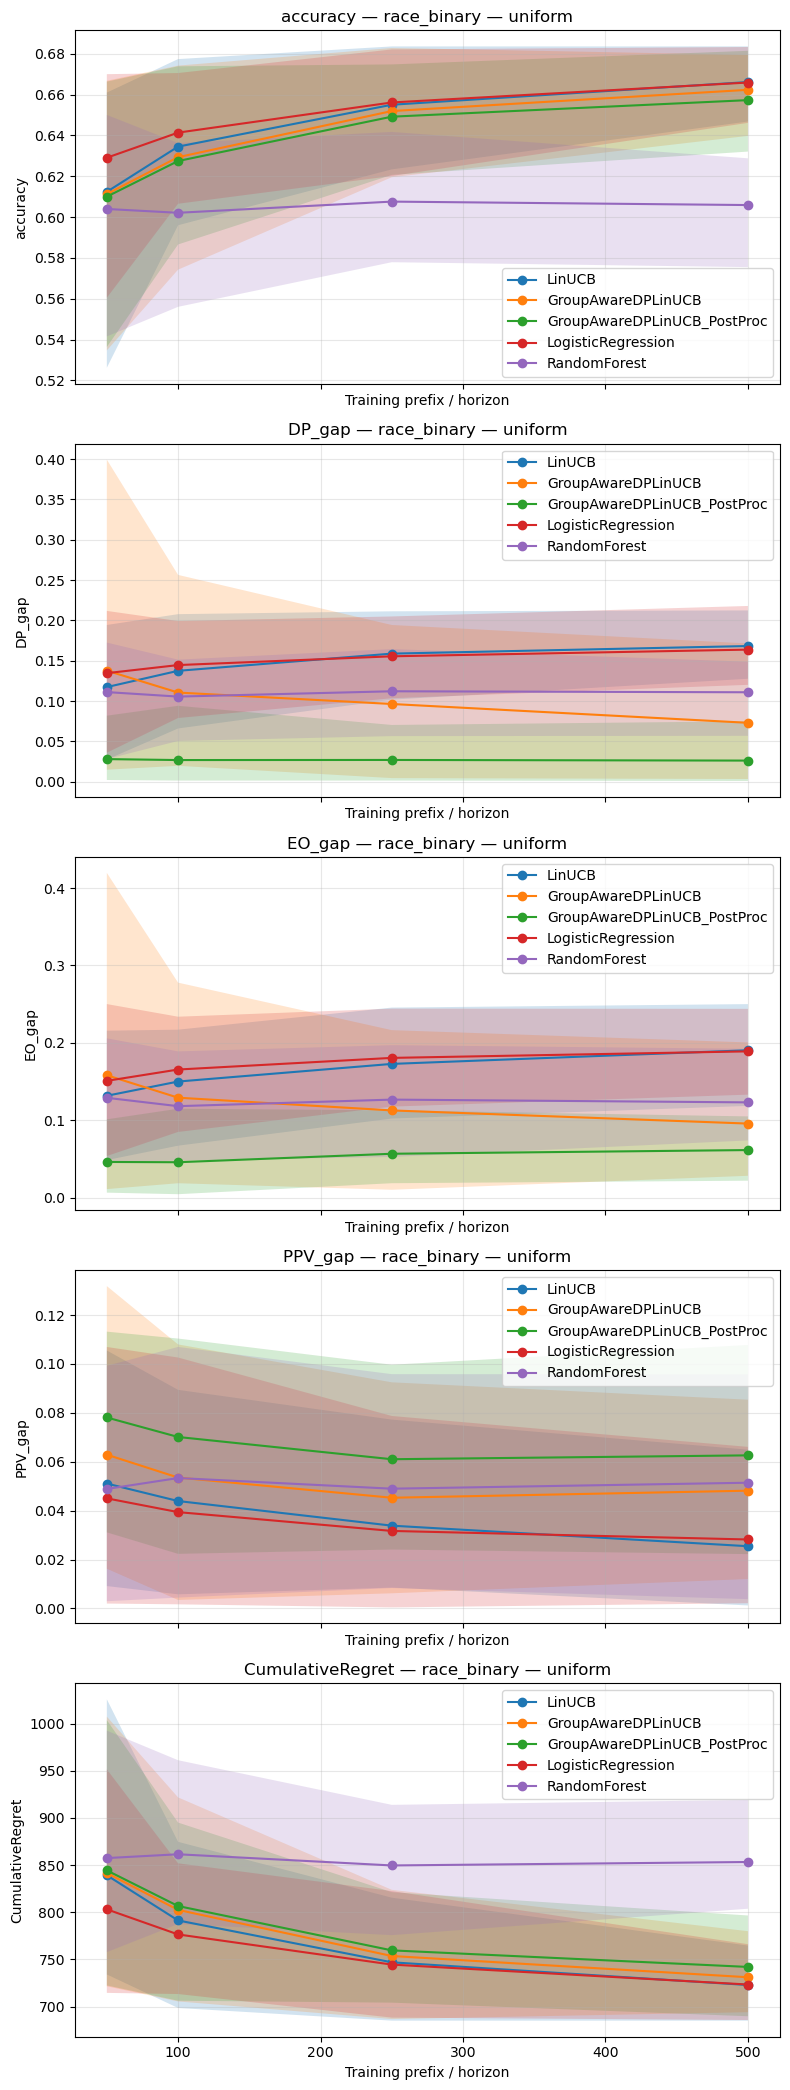

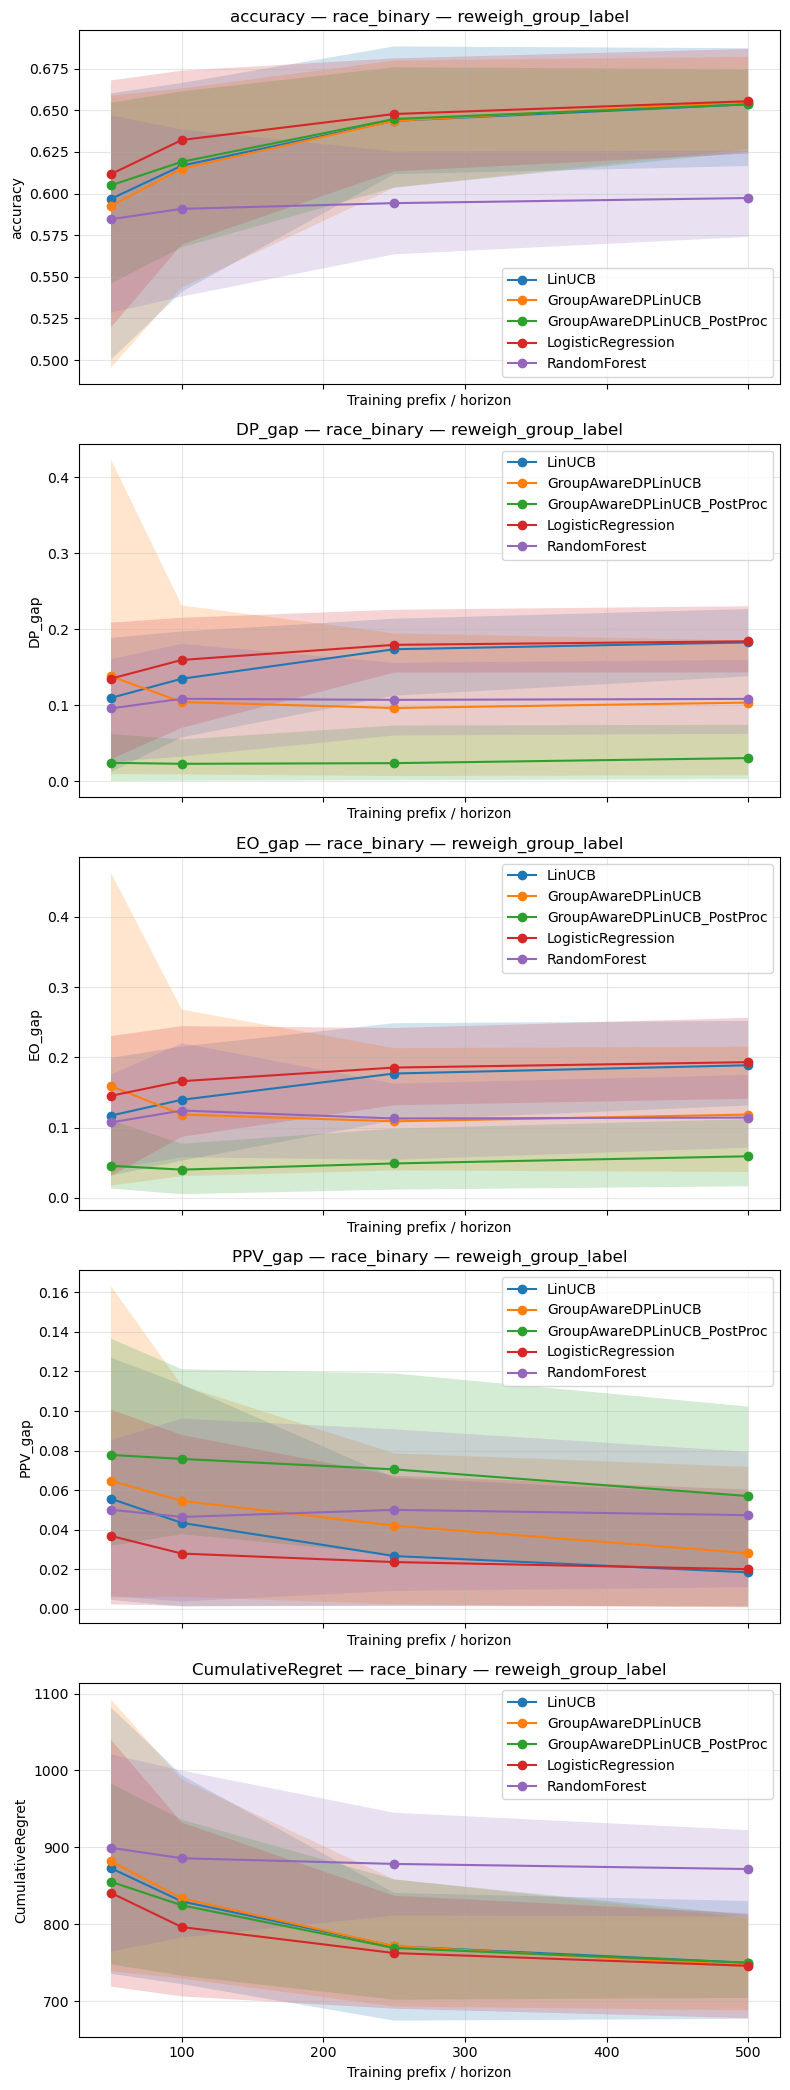

In [12]:
def plot_postproc_metric_across_horizons(
    ci_df: pd.DataFrame,
    *,
    metric: str,
    sensitive: str,
    preprocessing: str,
    ax=None,
):
    sub = ci_df[
        (ci_df["dataset"] == DATASET_NAME) &
        (ci_df["sensitive"] == sensitive) &
        (ci_df["preprocessing"] == preprocessing) &
        (ci_df["metric"] == metric)
    ].copy()

    if sub.empty:
        raise ValueError(
            f"No data for metric={metric}, sensitive={sensitive}, preprocessing={preprocessing}"
        )

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    for method in METHOD_ORDER:
        d = sub[sub["method"] == method].sort_values("horizon")
        if d.empty:
            continue
        ax.plot(d["horizon"], d["mean"], marker="o", label=method)
        ax.fill_between(d["horizon"], d["ci_low"], d["ci_high"], alpha=0.2)

    ax.set_xlabel("Training prefix / horizon")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} — {sensitive} — {preprocessing}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    return ax


PLOT_METRICS = ["accuracy", "DP_gap", "EO_gap", "PPV_gap", "CumulativeRegret"]

for sensitive in SENSITIVE_COLS:
    for preprocessing in PREPROCESSINGS:
        fig, axes = plt.subplots(len(PLOT_METRICS), 1, figsize=(8, 4.2 * len(PLOT_METRICS)), sharex=True)
        if len(PLOT_METRICS) == 1:
            axes = [axes]

        for ax, metric in zip(axes, PLOT_METRICS):
            plot_postproc_metric_across_horizons(
                postproc_ci_long,
                metric=metric,
                sensitive=sensitive,
                preprocessing=preprocessing,
                ax=ax,
            )

        plt.tight_layout()
        plt.show()